In [8]:
import os
from matplotlib import Path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
import seaborn as sns
import pandas as pd
import datetime

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout, Flatten, Dense, Input, ReLU, BatchNormalization
from keras.utils import image_dataset_from_directory

DATASET_DIR = Path("../Dataset_final_split")
SAVE_DIR = Path("../Models")

In [ ]:
train_ds = image_dataset_from_directory(
    DATASET_DIR / "train", 
    batch_size=32, 
    image_size=(224, 224)
)
val_ds = image_dataset_from_directory(
    DATASET_DIR / "val",
    batch_size=32,
    image_size=(224, 224)
)

normalization = tf.keras.layers.Rescaling(1./255)
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

train_ds = train_ds.map(lambda x, y: (normalization(augmentation(x, training=True)), y))
val_ds = val_ds.map(lambda x, y: (normalization(x), y))

Found 22759 files belonging to 6 classes.


E0000 00:00:1781005862.567392   40740 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781005862.567833   41704 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781005862.595094   40740 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 4875 files belonging to 6 classes.


In [3]:
# train_dir = DATASET_DIR / "train"
# for class_dir in train_dir.iterdir():
#     class_path = train_dir / class_dir.name
#     if class_dir.is_dir():
#         num_images = len(os.listdir(class_path))
#         print(f"{class_dir.name}, Number of images: {num_images}")

labels = []

for _, label in train_ds:
    labels.extend(label.numpy())

classes = np.unique(labels)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)
class_weights_dict = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights)
}

In [4]:
def create_model():
    model = Sequential([
        Input(shape=(224, 224, 3)),

        Conv2D(32, (3, 3), padding='same'),
        BatchNormalization(),
        ReLU(),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), padding='same'),
        BatchNormalization(),
        ReLU(),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), padding='same'),
        BatchNormalization(),
        ReLU(),
        MaxPooling2D((2, 2)),

        Conv2D(256, (3, 3), padding='same'),
        BatchNormalization(),
        ReLU(),
        MaxPooling2D((2, 2)),

        # Conv2D(512, (3, 3), padding='same'),
        # BatchNormalization(),
        # ReLU(),
        # MaxPooling2D((2, 2)),
        
        Dropout(0.3),
    
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(len(classes), activation='softmax')
    ])
    return model

In [ ]:
SAVE_DIR = Path("../Models")

def train_model(model, name, optimizer=None, max_epochs=10):
    if (optimizer is None):
        optimizer = keras.optimizers.Adam(1e-3)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
  
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=max_epochs,
        class_weight=class_weights_dict,
        callbacks=[early_stopping]
    )
    return model, history

def plot_training(history, name):
    hist = history.history
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(hist['accuracy'], markersize=3, label='Train')
    ax1.plot(hist['val_accuracy'], markersize=3, label='Validation')
    
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title("Training vs Validation Accuracy")
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    ax2.plot(hist['loss'], markersize=3, label='Train')
    ax2.plot(hist['val_loss'], markersize=3, label='Validation')
    
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title("Training vs Validation Loss")
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(SAVE_DIR / "plots", exist_ok=True)
    plt.savefig(SAVE_DIR / "plots" / f"{name}.png", dpi=100)
    plt.show()

Epoch 1/40
712/712 ━━━━━━━━━━━━━━━━━━━━ 514s 719ms/step - accuracy: 0.3346 - loss: 1.4007 - val_accuracy: 0.2010 - val_loss: 2.1287
Epoch 2/40


W0000 00:00:1781006603.957087   43042 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


712/712 ━━━━━━━━━━━━━━━━━━━━ 510s 716ms/step - accuracy: 0.4370 - loss: 1.2532 - val_accuracy: 0.2074 - val_loss: 2.0629
Epoch 3/40


W0000 00:00:1781007114.091972   43042 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


712/712 ━━━━━━━━━━━━━━━━━━━━ 502s 704ms/step - accuracy: 0.5395 - loss: 1.0764 - val_accuracy: 0.4626 - val_loss: 1.3368
Epoch 4/40


...

W0000 00:00:1781013035.140834   43042 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


712/712 ━━━━━━━━━━━━━━━━━━━━ 484s 680ms/step - accuracy: 0.8833 - loss: 0.3090 - val_accuracy: 0.8121 - val_loss: 0.4963
Epoch 16/40
712/712 ━━━━━━━━━━━━━━━━━━━━ 490s 683ms/step - accuracy: 0.8840 - loss: 0.3071 - val_accuracy: 0.6909 - val_loss: 0.8322
Epoch 17/40


W0000 00:00:1781014009.141735   43042 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


712/712 ━━━━━━━━━━━━━━━━━━━━ 505s 708ms/step - accuracy: 0.8887 - loss: 0.2899 - val_accuracy: 0.7305 - val_loss: 0.8441


FileNotFoundError: [Errno 2] No such file or directory: '../Models/plots/baseline_cnn.png'

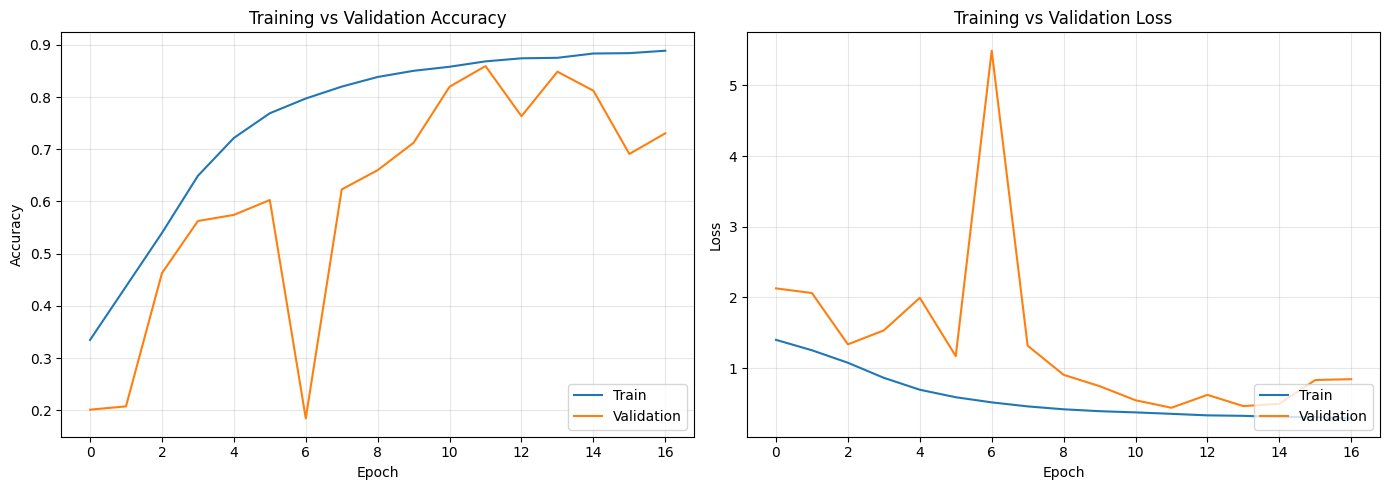

In [ ]:
model = create_model()
model, history = train_model(model, "baseline_cnn", max_epochs=40)
model.save(SAVE_DIR / "baseline_cnn.keras")

In [7]:
# plot_training(history, "baseline_cnn")
model = keras.models.load_model(SAVE_DIR / "baseline_cnn.keras")
model.summary()
test_ds = image_dataset_from_directory(
    DATASET_DIR / "test",
    batch_size=32,
    image_size=(224, 224)
)

normalization = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization(x), y))
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,371,092 (5.23 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 913,422 (3.48 MB)

Found 4882 files belonging to 6 classes.
153/153 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.8621 - loss: 0.4291
Test Loss: 0.42905282974243164, Test Accuracy: 0.8621466755867004


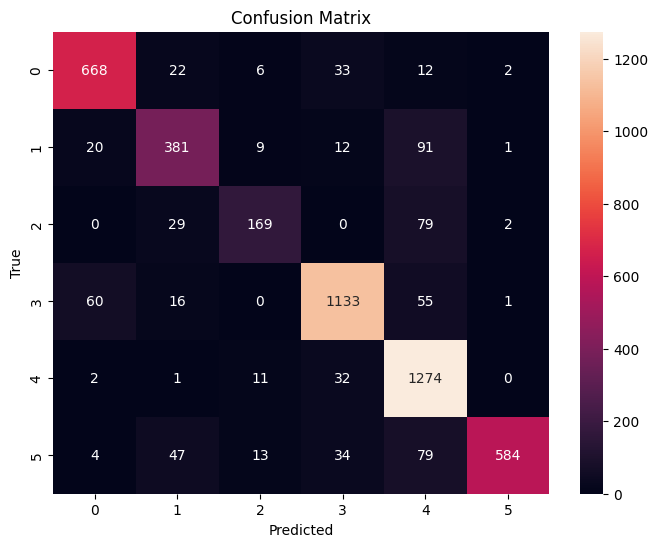

In [9]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()